In [6]:
import numpy as np
from matplotlib import pyplot as plt
import pickle
import pandas as pd
from tqdm import tqdm 

In [7]:
class Data:
    def __init__(self, array_list):
        self.array_list = array_list

    def save(self, filename):
        with open(filename, 'wb') as f:
            pickle.dump(self.array_list, f)

    @classmethod
    def load(cls, filename):
        with open(filename, 'rb') as f:
            array_list = pickle.load(f)
        return cls(array_list)
    
def load_individual_trajectory(filename):
    """Load a single trajectory from pickle file - no changes needed"""
    with open(filename, 'rb') as f:
        data = pickle.load(f)
    
    print(f"Loaded trajectory: {data['metadata']['trajectory_name']}")
    print(f"  Frame count: {data['metadata']['frame_count']}")
    print(f"  Parameters: {data['metadata']['parameters']}")
    
    return data

def load_convergence_data(filename):
    """Load convergence data from pickle file"""
    with open(filename, 'rb') as f:
        data = pickle.load(f)
    
    print("Loaded data summary:")
   # print(f"  Timestamp: {data['metadata']['timestamp']}")
    print(f"  Number of walkers: {data['metadata']['n_walkers']}")
    print(f"  Total frames per walker: {data['metadata']['walker_frame_counts']}")
    print(f"  Parameters: {data['metadata']['parameters']}")
    
    return data

### 8omg

In [8]:
import pandas as pd

df_stationary_p = pd.read_csv("autocooreldata/autocoorel_data_omg8rep/trans_population_at_lagtime_8conforms.csv")
print(df_stationary_p)

# Set 'conform_state' as index instead of pivot
pivot_mean = df_stationary_p.set_index('conform_state')['mean']
pivot_std = df_stationary_p.set_index('conform_state')['std']

# Convert to NumPy arrays
trans_refer_array = pivot_mean.to_numpy()
trans_refer_err_array = pivot_std.to_numpy()

print("Array shape:", trans_refer_array.shape)
print(trans_refer_array)


   conform_state  lagtime_index  lagtime_ns      mean       std
0              0              6         2.2  0.081357  0.010957
1              1              6         2.2  0.093396  0.010657
2              2              6         2.2  0.076178  0.008522
3              3              6         2.2  0.086172  0.011123
4              4              6         2.2  0.147792  0.011585
5              5              6         2.2  0.191021  0.013323
6              6              6         2.2  0.146395  0.017803
7              7              6         2.2  0.177689  0.011617
Array shape: (8,)
[0.08135737 0.0933961  0.07617768 0.08617183 0.14779227 0.19102109
 0.14639486 0.1776888 ]


Loaded data summary:
  Number of walkers: 8
  Total frames per walker: {1: 207776, 2: 207776, 3: 207776, 4: 207776, 5: 207776, 6: 207776, 7: 207776, 8: 207776}
  Parameters: {'window_size': 1000, 'dt': 0.002, 'temperature': 2.5, 'normalization': 'minimum'}


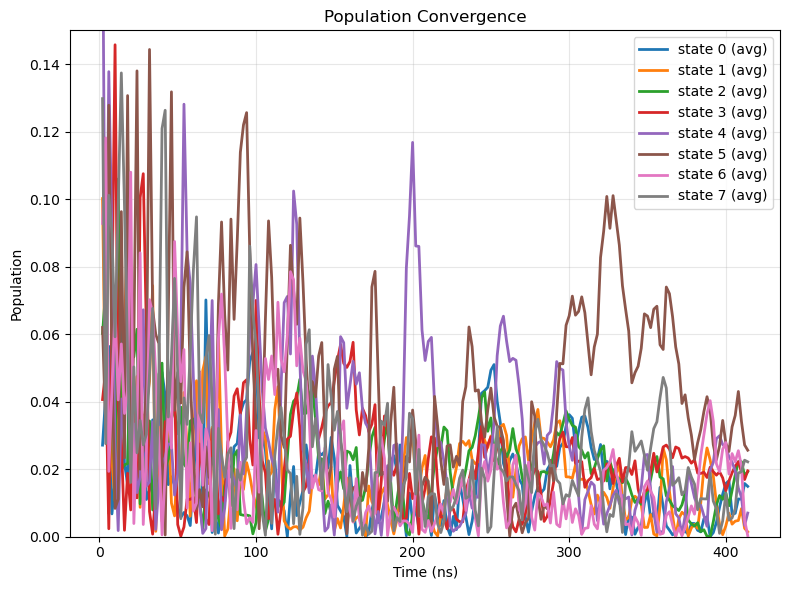

In [9]:
# Later, load and plot
omg8rep_meta_data = load_convergence_data(f"convergence_data/8omg_metadynamics_convergence.pkl")

errors_all = []

# Extract data
averaged_conv = omg8rep_meta_data['averaged_convergence']
individual_conv = omg8rep_meta_data.get('individual_walker_convergence', {})
state_labels = omg8rep_meta_data['metadata']['state_labels']
dt = omg8rep_meta_data['metadata']['parameters']['dt']

# Convert to time
time_ps = [frame * dt for frame in averaged_conv['frames']]
states_to_plot = range(1, 9)

plt.figure(figsize=(8, 6))

pops_all = []
errors_all = []
# reindex the plot 
for i, state in enumerate(states_to_plot):
    pops = averaged_conv['populations'][state]
    errors = averaged_conv['pop_std'][state]
    pops_all.append(pops)
    errors_all.append(errors)

pops_all = np.array(pops_all)
errors_all = np.array(errors_all)


pops_all_reindexed = pops_all.copy()
errors_all_reindexed = errors_all.copy()

pops_all_reindexed[3] = pops_all[6]
pops_all_reindexed[4] = pops_all[3]
pops_all_reindexed[6] = pops_all[4]

errors_all_reindexed[3] = errors_all[6]
errors_all_reindexed[4] = errors_all[3]
errors_all_reindexed[6] = errors_all[4]

omg_population_mean = pops_all_reindexed
omg_population_std = errors_all_reindexed

errors_all = []

for i in range(8):
    pops = pops_all_reindexed[i]
    errors = errors_all_reindexed[i]

    
    ref_pops = trans_refer_array[i]
    ref_errs = trans_refer_err_array[i]

    error = np.abs(ref_pops - pops)
    errors_all.append(error)

    plt.plot(time_ps, error, label=f'state {i} (avg)',
            linewidth=2)

plt.xlabel('Time (ns)')
plt.ylabel('Population')
plt.title('Population Convergence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 0.15)

plt.tight_layout()
plt.show()


In [10]:
import os 
errors_all = np.array(errors_all)
print(errors_all.shape)
errors_result = [errors_all]

os.makedirs('population_data', exist_ok=True)

data_instance = Data(errors_result)
data_instance.save("population_data/8omg_metadynamics_error_8_conform.pkl")

(8, 207)


## 8oppc

In [11]:
import pandas as pd

df_stationary_p = pd.read_csv("autocooreldata/autocoorel_data_oppc8rep/trans_population_at_lagtime_8conforms.csv")
print(df_stationary_p)

# Set 'conform_state' as index instead of pivot
pivot_mean = df_stationary_p.set_index('conform_state')['mean']
pivot_std = df_stationary_p.set_index('conform_state')['std']

# Convert to NumPy arrays
trans_refer_array = pivot_mean.to_numpy()
trans_refer_err_array = pivot_std.to_numpy()

print("Array shape:", trans_refer_array.shape)
print(trans_refer_array)


   conform_state  lagtime_index  lagtime_ns      mean       std
0              0              6         2.2  0.070003  0.009896
1              1              6         2.2  0.083030  0.012337
2              2              6         2.2  0.074649  0.020366
3              3              6         2.2  0.082610  0.017814
4              4              6         2.2  0.146876  0.018396
5              5              6         2.2  0.217434  0.040807
6              6              6         2.2  0.142872  0.010911
7              7              6         2.2  0.182527  0.025288
Array shape: (8,)
[0.07000262 0.08302984 0.07464873 0.08260975 0.14687599 0.21743441
 0.14287185 0.18252682]


Loaded data summary:
  Number of walkers: 8
  Total frames per walker: {1: 205058, 2: 205058, 3: 205058, 4: 205058, 5: 205058, 6: 205058, 7: 205058, 8: 205058}
  Parameters: {'window_size': 1000, 'dt': 0.002, 'temperature': 2.5, 'normalization': 'minimum'}


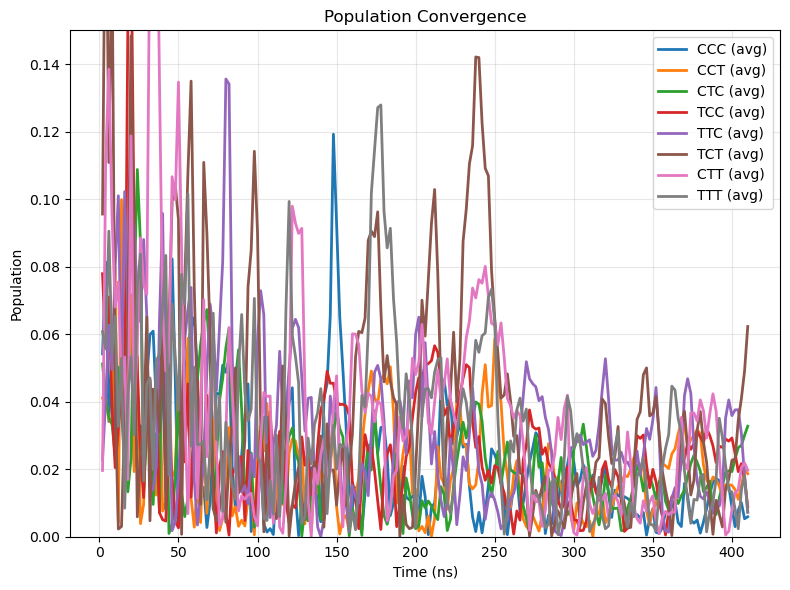

In [12]:
# Later, load and plot
omg8rep_meta_data = load_convergence_data(f"convergence_data/8oppc_metadynamics_convergence.pkl")

errors_all = []

# Extract data
averaged_conv = omg8rep_meta_data['averaged_convergence']
individual_conv = omg8rep_meta_data.get('individual_walker_convergence', {})
state_labels = omg8rep_meta_data['metadata']['state_labels']
dt = omg8rep_meta_data['metadata']['parameters']['dt']

# Convert to time
time_ps = [frame * dt for frame in averaged_conv['frames']]
states_to_plot = range(1, 9)

plt.figure(figsize=(8, 6))

pops_all = []
errors_all = []
# reindex the plot 
for i, state in enumerate(states_to_plot):
    pops = averaged_conv['populations'][state]
    errors = averaged_conv['pop_std'][state]
    pops_all.append(pops)
    errors_all.append(errors)

pops_all = np.array(pops_all)
errors_all = np.array(errors_all)


pops_all_reindexed = pops_all.copy()
errors_all_reindexed = errors_all.copy()

pops_all_reindexed[3] = pops_all[6]
pops_all_reindexed[4] = pops_all[3]
pops_all_reindexed[6] = pops_all[4]

errors_all_reindexed[3] = errors_all[6]
errors_all_reindexed[4] = errors_all[3]
errors_all_reindexed[6] = errors_all[4]

oppc_population_mean = pops_all_reindexed
oppc_population_std = errors_all_reindexed

errors_all = []

for i, state in enumerate(states_to_plot):
    pops = oppc_population_mean[i]
    errors = oppc_population_std[i]
    
    ref_pops = trans_refer_array[i]
    ref_errs = trans_refer_err_array[i]

    error = np.abs(ref_pops - pops)
    errors_all.append(error)

    plt.plot(time_ps, error, label=f'{state_labels[state]} (avg)',
            linewidth=2)

plt.xlabel('Time (ns)')
plt.ylabel('Population')
plt.title('Population Convergence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 0.15)

plt.tight_layout()
plt.show()


In [13]:
import os 
errors_all = np.array(errors_all)
print(errors_all.shape)
errors_result = [errors_all]

os.makedirs('population_data', exist_ok=True)

data_instance = Data(errors_result)
data_instance.save("population_data/8oppc_metadynamics_error_8_conform.pkl")

(8, 205)
